## Total Fuel Evaluation (Sum of Phase Models)

In this section, we evaluate total fuel consumption by combining the phase-level ML predictions.

Steps:
1. Load the November–December test flights from the feature table and obtain the ground-truth total fuel (`total_fuel_modeled`).  
   If a total column is not available, we compute it by summing the phase fuel columns.
2. Load phase prediction files (takeoff, climb, cruise, descent, landing) exported earlier as CSV.
3. Merge predictions by `flight_id` and set missing phase predictions to 0 (phase not present or not predicted).
4. Compute total predicted fuel as the sum of predicted phase fuels.
5. Merge predictions with ground truth and report overall error metrics (MAE and MAPE).
6. Print average predicted fuel per phase and inspect the largest absolute errors for debugging.

In [15]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DB_PATH = "../opensky.sqlite"
FEATURE_TABLE = "flight_phase_features_physics_weather"
YEAR = 2022

def add_datetime_from_flight_id(df: pd.DataFrame, year: int) -> pd.DataFrame:
    parts = df["flight_id"].astype(str).str.split("-", expand=True)
    month  = parts[2].astype(int)
    day    = parts[3].astype(int)
    hour   = parts[4].astype(int)
    minute = parts[5].astype(int)
    out = df.copy()
    out["flight_dt"] = pd.to_datetime(
        {"year": year, "month": month, "day": day, "hour": hour, "minute": minute},
        errors="coerce"
    )
    return out

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    return 100*np.mean(np.abs((y_true - y_pred)/np.clip(np.abs(y_true),1e-6,None)))

# --- load test truth ---
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql(f'SELECT * FROM "{FEATURE_TABLE}"', conn)
conn.close()

df = add_datetime_from_flight_id(df, YEAR)
df = df[df["flight_dt"].notna()].copy()
df["month"] = df["flight_dt"].dt.month
test = df[df["month"].isin([11,12])].copy()

true_total_col = "total_fuel_modeled"
if true_total_col not in test.columns:
    phase_cols = ["takeoff_fuel","climb_fuel","cruise_fuel","descent_fuel","landing_fuel"]
    test["true_total"] = test[phase_cols].sum(axis=1)
    true_total_col = "true_total"

truth = test[["flight_id", true_total_col]].rename(columns={true_total_col:"true_total"})

csv_dir = ("csv_files")
for fname in (
    "pred_physics_takeoff.csv",
    "pred_physics_climb.csv",
    "pred_physics_cruise.csv",
    "pred_physics_descent.csv",
    "pred_physics_landing.csv",
):
    full = os.path.join(csv_dir, fname)
    if not os.path.exists(full):
        raise FileNotFoundError(f"prediction file not found: {full}")

p_takeoff = pd.read_csv(os.path.join(csv_dir, "pred_physics_takeoff.csv"))
p_climb   = pd.read_csv(os.path.join(csv_dir, "pred_physics_climb.csv"))
p_cruise  = pd.read_csv(os.path.join(csv_dir, "pred_physics_cruise.csv"))
p_descent = pd.read_csv(os.path.join(csv_dir, "pred_physics_descent.csv"))
p_landing = pd.read_csv(os.path.join(csv_dir, "pred_physics_landing.csv"))

pred_all = (p_takeoff
    .merge(p_climb, on="flight_id", how="outer")
    .merge(p_cruise, on="flight_id", how="outer")
    .merge(p_descent, on="flight_id", how="outer")
    .merge(p_landing, on="flight_id", how="outer")
)

for c in ["pred_physics_takeoff","pred_physics_climb","pred_physics_cruise","pred_physics_descent","pred_physics_landing"]:
    pred_all[c] = pred_all[c].fillna(0.0)

pred_all["pred_total"] = pred_all[["pred_physics_takeoff","pred_physics_climb","pred_physics_cruise","pred_physics_descent","pred_physics_landing"]].sum(axis=1)

# merge truth
pred_all = pred_all.merge(truth, on="flight_id", how="left")

mask = pred_all["true_total"].notna() & np.isfinite(pred_all["true_total"])
y_true = pred_all.loc[mask, "true_total"].to_numpy(float)
y_pred = pred_all.loc[mask, "pred_total"].to_numpy(float)

print("TOTAL RESULTS (sum of phase ML)")
print("N:", int(mask.sum()))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("MAPE:", mape(y_true, y_pred))
print(f"MSE : {mean_squared_error(y_true, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")
print(f"R²  : {r2_score(y_true, y_pred):.4f}")



print(pred_all[[
    "pred_physics_takeoff",
    "pred_physics_climb",
    "pred_physics_cruise",
    "pred_physics_descent",
    "pred_physics_landing"
]].mean())

pred_all["abs_err"] = abs(pred_all["true_total"] - pred_all["pred_total"])
pred_all.sort_values("abs_err", ascending=False).head(10)

TOTAL RESULTS (sum of phase ML)
N: 3505
MAE: 73.21782935152572
MAPE: 4.4420686441007495
MSE : 9228.1099
RMSE: 96.0631
R²  : 0.9658
pred_physics_takeoff      45.865529
pred_physics_climb      1082.404513
pred_physics_cruise      258.870943
pred_physics_descent     341.764732
pred_physics_landing       9.761460
dtype: float64


,flight_id,pred_physics_takeoff,pred_physics_climb,pred_physics_cruise,pred_physics_descent,pred_physics_landing,pred_total,true_total,abs_err
2072,479ee7-NOZ50A-12-29-17-57,0.000000,1597.45810,1023.101132,343.71910,11.218862,2975.497194,4099.73,1124.232806
210,478742-NOZ628-12-21-17-45,48.866505,1151.13590,84.757835,347.37228,9.264266,1641.396786,2224.98,583.583214
1235,479227-NOZ602-12-13-08-23,50.329926,1122.84350,974.858622,517.36755,11.001999,2676.401597,3223.76,547.358403
2380,47a0bf-NOZ4RZ-12-23-07-39,0.000000,1619.12260,1554.832782,479.66300,18.361986,3671.980368,4204.72,532.739632
3466,4aca46-NOZ549-12-01-16-57,57.321540,1156.92150,451.241702,389.68295,11.577244,2066.744936,1558.29,508.454936
1515,4792db-NOZ145-12-01-16-01,54.651104,464.17053,0.000000,313.51540,9.042903,841.379937,1273.72,432.340063
1317,4792a6-NOZ522-12-08-06-12,48.935947,1090.06300,125.986597,403.50130,11.732752,1680.219596,2080.11,399.890404
294,47875c-NOZ143-12-18-15-15,48.435883,503.47910,0.000000,312.86862,9.999367,874.782970,1253.53,378.747030
2256,47a05e-NOZ544-12-01-17-08,52.408650,1144.19960,296.559551,356.81546,12.979465,1862.962727,1486.08,376.882727
2337,47a097-NOZ541-12-29-16-04,0.000000,1240.14930,293.643891,743.29220,8.313728,2285.399119,2649.24,363.840881


# Plot estimated vs actual total fuel

Removed 0 outliers (0.0%)


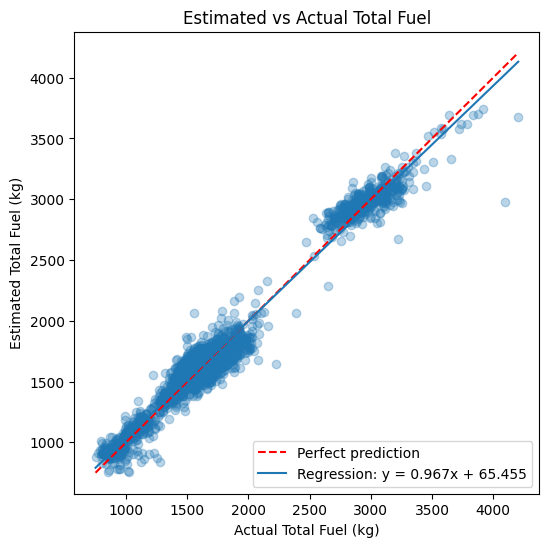

In [16]:
# Remove outliers (both over- and under-predictions)
before = len(pred_all)
pred_all = pred_all[
    (pred_all["pred_total"] <= 2 * pred_all["true_total"]) &
    (pred_all["pred_total"] >= 0.5 * pred_all["true_total"])
]
after = len(pred_all)

print(f"Removed {before - after} outliers ({(before - after)/before:.1%})")

plt.figure(figsize=(6,6))

plt.scatter(
    pred_all["true_total"],
    pred_all["pred_total"],
    alpha=0.3
)

# Perfect prediction line
min_val = pred_all["true_total"].min()
max_val = pred_all["true_total"].max()

plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Perfect prediction")

# Regression line (actual trend)
m, b = np.polyfit(pred_all["true_total"], pred_all["pred_total"], 1)
x_line = np.linspace(min_val, max_val, 100)
plt.plot(x_line, m*x_line + b, label=f"Regression: y = {m:.3f}x + {b:.3f}")

plt.xlabel("Actual Total Fuel (kg)")
plt.ylabel("Estimated Total Fuel (kg)")
plt.title("Estimated vs Actual Total Fuel")
plt.legend()
plt.legend(loc="lower right")
plt.show()

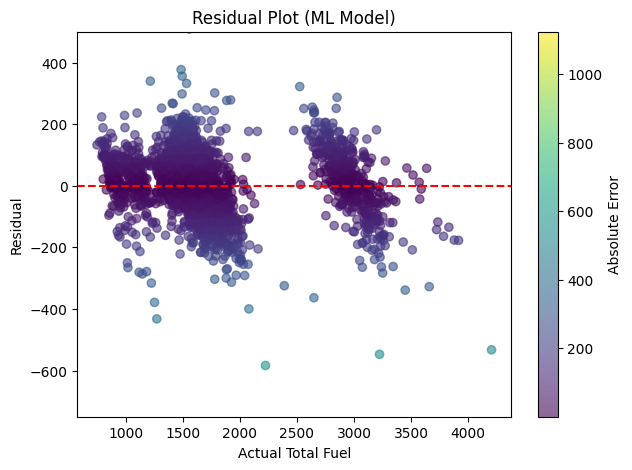

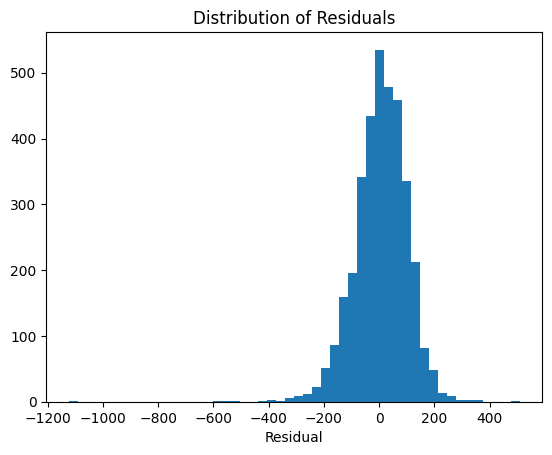

In [17]:
# compute residual (prediction - truth) if not already computed
if "residual" not in pred_all.columns:
    pred_all["residual"] = pred_all["pred_total"] - pred_all["true_total"]

plt.figure(figsize=(7,5))

plt.ylim(-750, 500)

plt.scatter(
    pred_all["true_total"],
    pred_all["residual"],
    c=pred_all["abs_err"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(label="Absolute Error")
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Actual Total Fuel")
plt.ylabel("Residual")
plt.title("Residual Plot (ML Model)")

plt.show()

plt.hist(pred_all["residual"], bins=50)
plt.xlabel("Residual")
plt.title("Distribution of Residuals")
plt.show()

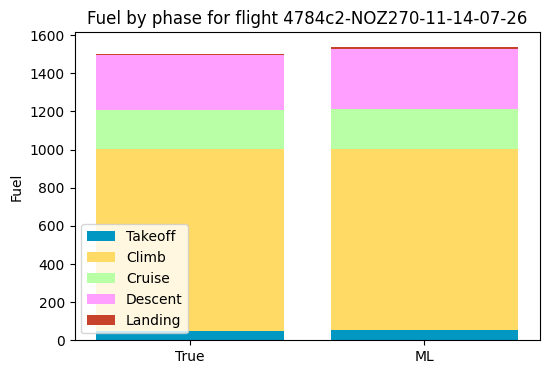

In [18]:
phases_true = [
    "takeoff_fuel",
    "climb_fuel",
    "cruise_fuel",
    "descent_fuel",
    "landing_fuel"
]

phases_pred = [
    "pred_physics_takeoff",
    "pred_physics_climb",
    "pred_physics_cruise",
    "pred_physics_descent",
    "pred_physics_landing"
]

colors = {
    "takeoff_fuel": "#0098c2",
    "climb_fuel": "#ffdb66",
    "cruise_fuel": "#b8ffa5",
    "descent_fuel": "#ff9fff",
    "landing_fuel": "#c7422b"
}


phase_truth = test[[
    "flight_id",
    "takeoff_fuel",
    "climb_fuel",
    "cruise_fuel",
    "descent_fuel",
    "landing_fuel"
]].drop_duplicates("flight_id")

pred_all = pred_all.merge(phase_truth, on="flight_id", how="left")

row = pred_all.iloc[3]

fig, ax = plt.subplots(figsize=(6,4))

bottom_true = 0
bottom_pred = 0

for true_col, pred_col in zip(phases_true, phases_pred):

    ax.bar(
        "True",
        row[true_col],
        bottom=bottom_true,
        color=colors[true_col],
        label=true_col.replace("_fuel","").capitalize()
    )

    ax.bar(
        "ML",
        row[pred_col],
        bottom=bottom_pred,
        color=colors[true_col]
    )

    bottom_true += row[true_col]
    bottom_pred += row[pred_col]

ax.set_ylabel("Fuel")
ax.set_title(f"Fuel by phase for flight {row['flight_id']}")

ax.legend()

plt.show()

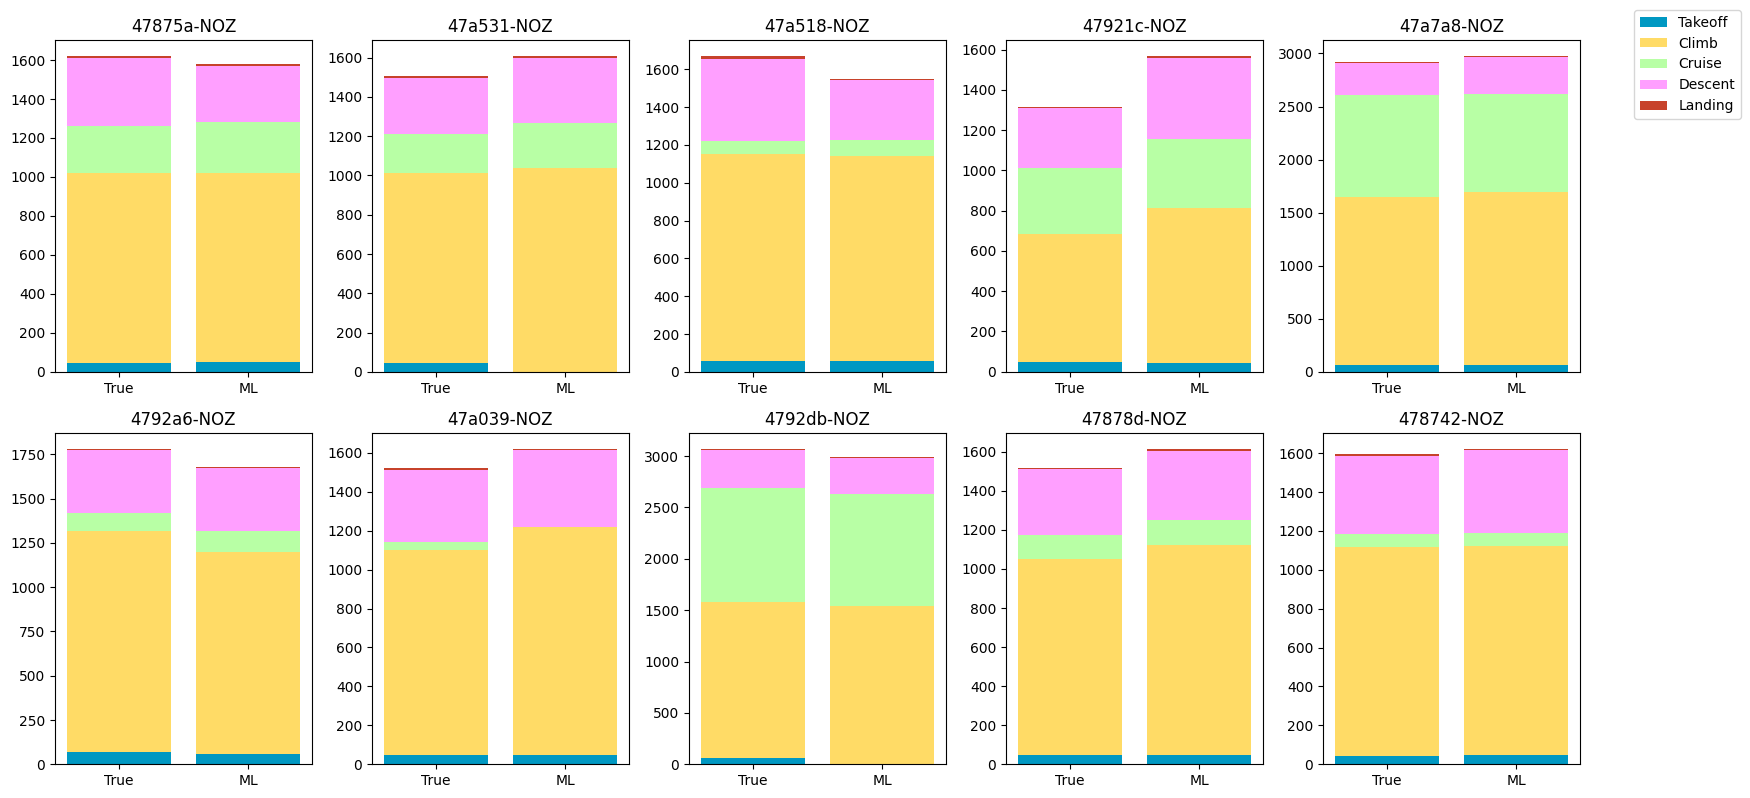

In [ ]:
n = 10
sample = pred_all.sample(n, random_state=3)

cols = 5
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(16,4*rows))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample.iterrows()):

    bottom_true = 0
    bottom_pred = 0

    for true_col, pred_col in zip(phases_true, phases_pred):

        label = true_col.replace("_fuel","").capitalize()

        ax.bar(
            "True",
            row[true_col],
            bottom=bottom_true,
            color=colors[true_col],
            label=label
        )

        ax.bar(
            "ML",
            row[pred_col],
            bottom=bottom_pred,
            color=colors[true_col]
        )

        bottom_true += row[true_col]
        bottom_pred += row[pred_col]

    ax.set_title(row["flight_id"][:10])
    ax.set_xticks([0,1])
    ax.set_xticklabels(["True","ML"])

# remove empty subplots
for ax in axes[n:]:
    ax.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()
plt.show()

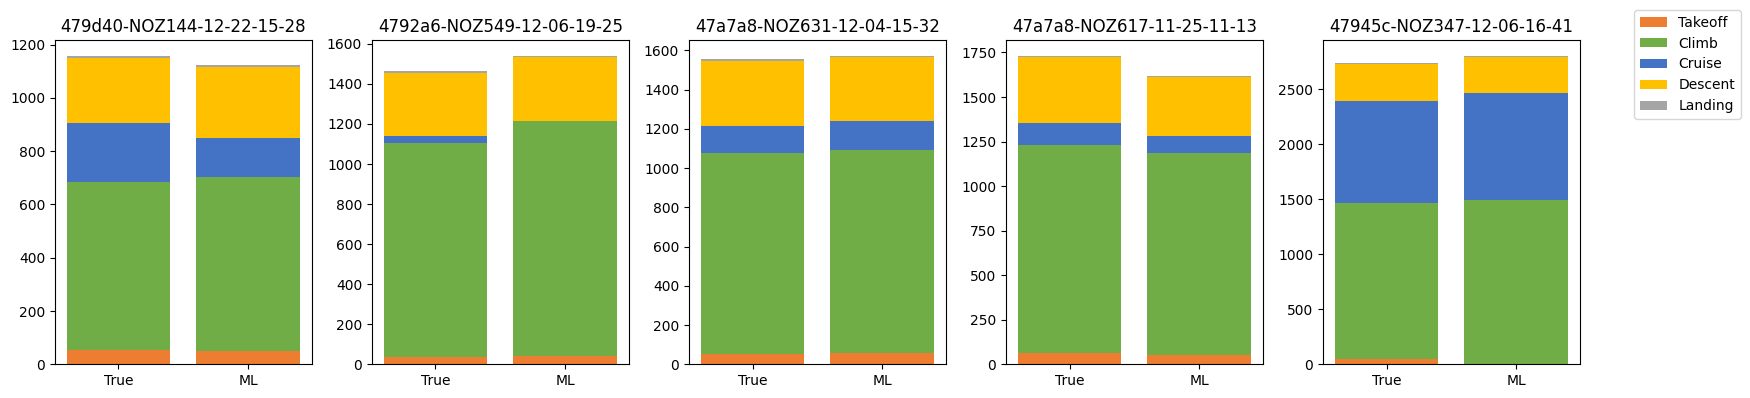

In [20]:
n = 5
sample = pred_all.sample(n)

cols = 5
rows = 1

fig, axes = plt.subplots(rows, cols, figsize=(16,4))
axes = axes.flatten()

colors = {
    "takeoff_fuel": "#c7422b",
    "climb_fuel": "#ff9fff",
    "cruise_fuel": "#ffdb66",
    "descent_fuel": "#b8ffa5",
    "landing_fuel": "#0098c2"
}
colors = {
    "takeoff_fuel": "#ED7D31",     # orange
    "climb_fuel": "#70AD47",    # green
    "cruise_fuel": "#4472C4",   # blue
    "descent_fuel": "#FFC000",   # yellow
    "landing_fuel": "#A5A5A5"    # grey
}

for ax, (_, row) in zip(axes, sample.iterrows()):

    bottom_true = 0
    bottom_pred = 0

    for true_col, pred_col in zip(phases_true, phases_pred):

        label = true_col.replace("_fuel","").capitalize()

        ax.bar(
            "True",
            row[true_col],
            bottom=bottom_true,
            color=colors[true_col],
            label=label
        )

        ax.bar(
            "ML",
            row[pred_col],
            bottom=bottom_pred,
            color=colors[true_col]
        )

        bottom_true += row[true_col]
        bottom_pred += row[pred_col]

    ax.set_title(row["flight_id"])   # full id
    ax.set_xticks([0,1])
    ax.set_xticklabels(["True","ML"])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()
plt.show()